### Fig. 6: Regression of annual mean 1) subsurface densities and 2) vertical Ekman velocity onto the throughput time series

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cartopy
import os
import dask.config  
import gsw 
import warnings
warnings.filterwarnings("ignore")

#os.environ["OMP_NUM_THREADS"] = "8" 

In [2]:
# Throughput time series (1990-2017)

# Upload saved data (saved in part_quant_1990-2017.py)
dir_quant='YOUR_DATA_PATH' #directory for .csv file
df_spg = pd.read_csv(dir_quant+'vtSPG_an_1990-2017_data.csv') #read the CSV file 

VTanSPG = df_spg.vtSPG.values/1e+6/12 #annual mean VT in Sverdrup

In [3]:
# GO8p7-eORCA12 grid paths
data_path = 'YOUR_MODEL_DATA_PATH'
grid_path = 'YOUR_GRID_PATH'

ds93T = xr.open_dataset(data_path+'T/nemo_g8p7ho_1m_199301_grid-T.nc')
lev = ds93T.thetao_con.deptht
ds93T.close()

lev_100=23

In [4]:
# Read in subsurface densities 100m (1990-2021)
files = [os.path.join(data_path+'T/', f) for f in os.listdir(data_path+'T/') if f.startswith('nemo_g8p7ho_1m_') and f.endswith('_grid-T.nc')]
files = sorted(files)
files = files[132:]  #limit to 1990-2021

temp_list = []
sal_list = []
f=0

with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    for file in files: #loop over files
        f=f+1
        #print(f)
        
        ds = xr.open_dataset(file)
        
        temp  = ds.thetao_con.isel(deptht=lev_100).squeeze(dim='time_counter')
        sal  = ds.so_abs.isel(deptht=lev_100).squeeze(dim='time_counter')
        
        temp_list.append(temp)
        sal_list.append(sal)
        
        ds.close()
del temp, sal, ds
        
# Concatenate all the data in the lists
temp_mon = xr.concat(temp_list, dim='time')
sal_mon  = xr.concat(sal_list, dim='time')
del temp_list, sal_list

In [5]:
# Calculate potential density
dens_mon = gsw.density.sigma0(sal_mon, temp_mon)
del sal_mon, temp_mon

In [6]:
# Grid variables 
ds_grid = xr.open_dataset(grid_path+'mesh_hgr_NH.nc')

DXv = np.squeeze(ds_grid['e1v'].values)
DYu = np.squeeze(ds_grid['e2u'].values)

# longitude and latitude of vorticity point (northeast corner of grid cell)
lonf = np.squeeze(ds_grid['glamf'].values)
latf = np.squeeze(ds_grid['gphif'].values)

# longitude and latitude of tracer point (center of grid cell)
lont = np.squeeze(ds_grid['glamt'].values)
latt = np.squeeze(ds_grid['gphit'].values)


In [7]:
# Wind stress (1990-2021)
filesTU = [os.path.join(data_path+'U/tauuo/', f) for f in os.listdir(data_path+'U/tauuo/') if f.startswith('nemo_g8p7ho_1m_')]
filesTU = sorted(filesTU)
filesTV = [os.path.join(data_path+'V/tauvo/', f) for f in os.listdir(data_path+'V/tauvo/') if f.startswith('nemo_g8p7ho_1m_')]
filesTV = sorted(filesTV) 

filesTU = filesTU[132:] #limit to 1990-2021
filesTV = filesTV[132:]

# Lists to hold the data
tauu_list = []
tauv_list = []

with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    for ii in range(0,len(filesTU)):
        #print(ii)
    
        dsTU = xr.open_dataset(filesTU[ii],chunks={})
        dsTV = xr.open_dataset(filesTV[ii],chunks={})
        
        tauu  = dsTU.tauuo.squeeze(dim='time_counter')
        tauv  = dsTV.tauvo.squeeze(dim='time_counter')

        # Append data to the lists when looping
        tauu_list.append(tauu)
        tauv_list.append(tauv)
        
        dsTU.close()
        dsTV.close()
del tauu, tauv, dsTU, dsTV
        
# Concatenate all the data in the lists
tauu_mon  = xr.concat(tauu_list, dim='time', coords="minimal", compat="override")
tauv_mon  = xr.concat(tauv_list, dim='time', coords="minimal", compat="override")
del tauu_list, tauv_list


In [8]:
# Calculation prep. wind stress curl 
tauu_mon = tauu_mon.values
tauv_mon = tauv_mon.values

# set nans to zero
tauu_mon = np.nan_to_num(tauu_mon, copy=False, nan=0)
tauv_mon = np.nan_to_num(tauv_mon, copy=False, nan=0)

# dimensions
Nt=len(tauu_mon[:,0,0])
Nj=len(tauu_mon[0,:,0]) #y-dim
Ni=len(tauu_mon[0,0,:]) #x-dim

# Coriolis parameter
import math
rhozero=1035;                  #reference density [kg/m³]
omega = (2*math.pi)/(24*3600); #angular rotation of Earth [rad/s]
a=6371*1000;                   #Earth radius 6371 km [m]
f = 2 * omega * np.sin(np.radians(latf)) #np.radians convert from degrees to radians

In [9]:
# Calculating vertical Ekman velocity from wind stress curl
# y-dim is the first spatial dim, x-dim is the second spatial dim
# Do the differencing to that take advatage of the C-grid --> co-location in vorticity point (northeast corner)
# no need for centering when points are co-located

tauU_fdy = np.zeros([Nt, Nj, Ni])
tauV_fdx = np.zeros([Nt, Nj, Ni])

# Wind stress divivded by Coriolis parameter
tauv_f = tauv_mon/f #divide 3d by 2d 
tauu_f = tauu_mon/f

# Compute gradients
for tt in range(Nt):
    tauV_fdx[tt,:,:-1] = (tauv_f[tt,:,1:] - tauv_f[tt,:,:-1]) / DXv[:,:-1]
    tauU_fdy[tt,:-1,:] = (tauu_f[tt,1:,:] - tauu_f[tt,:-1,:]) / DYu[:-1,:]
del tauv_f, tauu_f

# Curl computation
wEk_mon = (1/rhozero)*(tauV_fdx - tauU_fdy) #Unit: N/m^3


In [10]:
# Crop variables - North Atlantic only

# Potential density 100m
NAdens_mon = dens_mon[:,100:,2200:4000]
del dens_mon
NAlatt = latt[100:,2200:4000]
del latt
NAlont = lont[100:,2200:4000]
del lont

# Ekman velocity
NAwEk_mon = wEk_mon[:,100:,2200:4000]
del wEk_mon
NAlatf = latf[100:,2200:4000]
del latf
NAlonf = lonf[100:,2200:4000]
del lonf

In [11]:
# Annual mean   
y=2021-1990+1
ii=0 #count

Nt = len(NAdens_mon[:,0,0])
Ni = len(NAdens_mon[0,:,0])
Nj = len(NAdens_mon[0,0,:])

dens_an=np.zeros([y,Ni,Nj])
wEk_an =np.zeros([y,Ni,Nj])

for m in range(0,Nt,12):    
    dens_an[ii,:,:] = np.nanmean(NAdens_mon[m:m+12,:,:],axis=0)
    wEk_an[ii,:,:] = np.nanmean(NAwEk_mon[m:m+12,:,:],axis=0)
    
    ii=ii+1
del NAdens_mon, NAwEk_mon

In [12]:
# REGRESSION (W. LAG)
from scipy import stats

# standardize throughput time series
Xspg = (VTanSPG - np.mean(VTanSPG)) / np.std(VTanSPG)   

Y1 = dens_an
Y2 = wEk_an

lag = [0,1,2]

NiY=len(Y1[0,:,0])
NjY=len(Y1[0,0,:])
NtY=len(Y1[:,0,0]) #32 years
NtX=len(Xspg)      #28 years

REGspg_dens = np.zeros((NiY,NjY,len(lag)))
PVALspg_dens = np.zeros((NiY,NjY,len(lag)))
REGspg_wEk = np.zeros((NiY,NjY,len(lag)))
PVALspg_wEk = np.zeros((NiY,NjY,len(lag)))

for ll in range(0,len(lag)):
    print(lag[ll])
    
    for ii in range(0,Ni):
        for jj in range(0,Nj):
            res1 = stats.linregress(Xspg[0:NtX],Y1[(0+lag[ll]):NtX+lag[ll],ii,jj], alternative='two-sided')
            REGspg_dens[ii,jj,ll]  = res1.slope 
            PVALspg_dens[ii,jj,ll] = res1.pvalue 
        
            res2 = stats.linregress(Xspg[0:NtX],Y2[(0+lag[ll]):NtX+lag[ll],ii,jj], alternative='two-sided')
            REGspg_wEk[ii,jj,ll]  = res2.slope
            PVALspg_wEk[ii,jj,ll] = res2.pvalue 
del Y1, Y2

0
1
2


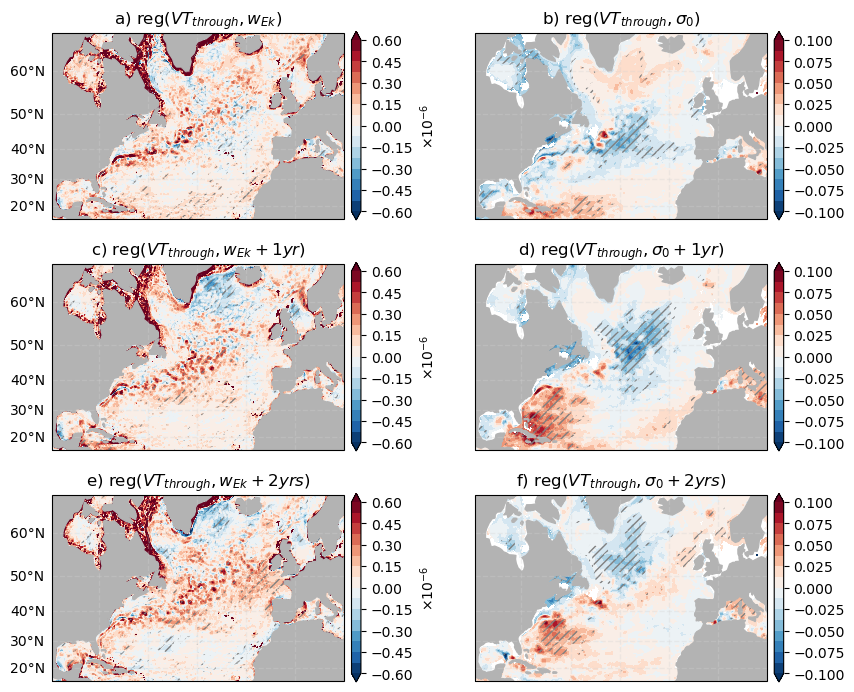

In [13]:
# Plotting Fig. 5
from cartopy import crs
import cartopy.feature as cfeatures

data_proj = crs.PlateCarree( )  #Projection our data is in
display_proj = crs.Mercator()   #Projection to display in

REGspg_wEk6=REGspg_wEk/1e-6

fig, ax = plt.subplots(nrows=3,ncols=2,figsize=(10, 8.5),subplot_kw={'projection': display_proj})
plt.rcParams.update({'hatch.color': 'grey'})

##### Ekman vel. reg. ######
ax[0,0].set_extent([-99,20,15,67],crs=data_proj)
ax[0,0].add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g=ax[0,0].gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
ax[0,0].set_title('a) reg($VT_{through},w_{Ek}$)')
g.xlabels_bottom = False
g.ylabels_right = False
g.xlabels_top = False
#
ctrs1=ax[0,0].contourf(NAlonf,NAlatf,REGspg_wEk6[:,:,0], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.6,0.6,17), extend='both') 
cbar1 = plt.colorbar(ctrs1,ax=ax[0,0],label=r'$\times 10^{-6}$',pad=0.02, shrink=0.98) 
hatch1=ax[0,0].contourf(NAlonf,NAlatf,PVALspg_wEk[:,:,0], transform = data_proj,levels=[0,0.1],hatches=['////',None],colors='none')

ax[1,0].set_extent([-99,20,15,67],crs=data_proj)
ax[1,0].add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g=ax[1,0].gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
ax[1,0].set_title('c) reg($VT_{through},w_{Ek} + 1 yr$)')
g.xlabels_bottom = False
g.ylabels_right = False
g.xlabels_top = False
#
ctrs2=ax[1,0].contourf(NAlonf,NAlatf,REGspg_wEk6[:,:,1], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.6,0.6,17), extend='both') 
cbar2 = plt.colorbar(ctrs2,ax=ax[1,0],label=r'$\times 10^{-6}$',pad=0.02,shrink=0.98) 
hatch2=ax[1,0].contourf(NAlonf,NAlatf,PVALspg_wEk[:,:,1], transform = data_proj,levels=[0,0.1],hatches=['////',None],colors='none')

ax[2,0].set_extent([-99,20,15,67],crs=data_proj)
ax[2,0].add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g=ax[2,0].gridlines( draw_labels = True, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
ax[2,0].set_title('e) reg($VT_{through},w_{Ek} + 2 yrs$)')
g.xlabels_bottom = False
g.ylabels_right = False
g.xlabels_top = False
#
ctrs3=ax[2,0].contourf(NAlonf,NAlatf,REGspg_wEk6[:,:,2], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.6,0.6,17), extend='both') 
cbar3 = plt.colorbar(ctrs3,ax=ax[2,0],label=r'$\times 10^{-6}$',pad=0.02, shrink=0.98)
hatch3=ax[2,0].contourf(NAlonf,NAlatf,PVALspg_wEk[:,:,2], transform = data_proj,levels=[0,0.1],hatches=['////',None],colors='none')
    
##### potential density reg. ######
ax[0,1].set_extent([-99,20,15,67],crs=data_proj)
ax[0,1].add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g=ax[0,1].gridlines( draw_labels = False, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
ax[0,1].set_title('b) reg($VT_{through},\sigma_0$)')
#
ctrs4=ax[0,1].contourf(NAlont,NAlatt,REGspg_dens[:,:,0], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.1,0.1,17), extend='both') 
cbar4 = plt.colorbar(ctrs4,ax=ax[0,1],label='',pad=0.02, shrink=0.98)
hatch4=ax[0,1].contourf(NAlont,NAlatt,PVALspg_dens[:,:,0], transform = data_proj,levels=[0,0.1],hatches=['////',None],colors='none')

ax[1,1].set_extent([-99,20,15,67],crs=data_proj)
ax[1,1].add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g=ax[1,1].gridlines( draw_labels = False, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
ax[1,1].set_title('d) reg($VT_{through},\sigma_0 + 1 yr$)')
#
ctrs5=ax[1,1].contourf(NAlont,NAlatt,REGspg_dens[:,:,1], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.1,0.1,17), extend='both') 
cbar5 = plt.colorbar(ctrs5,ax=ax[1,1],label='',pad=0.02,shrink=0.98) 
hatch5=ax[1,1].contourf(NAlont,NAlatt,PVALspg_dens[:,:,1], transform = data_proj,levels=[0,0.1],hatches=['////',None],colors='none')

ax[2,1].set_extent([-99,20,15,67],crs=data_proj)
ax[2,1].add_feature(cfeatures.LAND,edgecolor=(.3, .3, .3),color=(.7, .7, .7),zorder=2)
g=ax[2,1].gridlines( draw_labels = False, linewidth = 1, color = 'lightgrey',alpha = 0.3, linestyle = '--')  
ax[2,1].set_title('f) reg($VT_{through},\sigma_0 + 2 yrs$)')
#
ctrs6=ax[2,1].contourf(NAlont,NAlatt,REGspg_dens[:,:,2], transform = data_proj,cmap='RdBu_r',levels=np.linspace(-0.1,0.1,17), extend='both') 
cbar6 = plt.colorbar(ctrs6,ax=ax[2,1],label='',pad=0.02, shrink=0.98) 
hatch6=ax[2,1].contourf(NAlont,NAlatt,PVALspg_dens[:,:,2], transform = data_proj,levels=[0,0.1],hatches=['////',None],colors='none')
